# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Ahmad Alzakki
- **Email:** FS220B6Y0081@student.devacademy.id
- **ID Dicoding:** FS220B6Y0081

## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren jumlah pesanan dan total pendapatan (revenue) per bulan di platform e-commerce ini selama periode September 2016 hingga Agustus 2018, dan pada bulan apa terjadi peningkatan tertinggi secara month-over-month?**
2. **Bagaimana distribusi segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) pada data transaksi e-commerce ini hingga Agustus 2018, dan segmen pelanggan mana yang paling bernilai serta paling berisiko untuk churn?**
3. **Bagaimana distribusi geografis pelanggan berdasarkan negara bagian (state) di Brasil, dan state mana yang memberikan kontribusi pendapatan terbesar selama periode 2016-2018?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat semua dataset yang dibutuhkan ke dalam format DataFrame. Dataset yang digunakan adalah E-Commerce Public Dataset yang terdiri dari 8 tabel utama.

In [ ]:
# Load semua dataset
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
sellers_df = pd.read_csv("data/sellers_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")

print("Dataset berhasil dimuat!")
print(f"Orders: {orders_df.shape}")
print(f"Order Items: {order_items_df.shape}")
print(f"Order Payments: {order_payments_df.shape}")
print(f"Order Reviews: {order_reviews_df.shape}")
print(f"Customers: {customers_df.shape}")
print(f"Products: {products_df.shape}")
print(f"Sellers: {sellers_df.shape}")
print(f"Category Translation: {category_translation_df.shape}")

Dataset berhasil dimuat!
Orders: (99441, 8)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


#### Tabel Orders

In [ ]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


#### Tabel Order Items

In [ ]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


#### Tabel Order Payments

In [ ]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Tabel Order Reviews

In [ ]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#### Tabel Customers

In [ ]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Tabel Products

In [ ]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Tabel Sellers

In [ ]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Assessing Data

Pada tahap ini, kita akan menilai kualitas data dengan memeriksa beberapa permasalahan umum seperti: **missing values**, **duplicate data**, **invalid values**, dan **tipe data yang tidak sesuai**.

#### 1. Memeriksa Missing Values

In [ ]:
print("=" * 60)
print("MISSING VALUES PER DATASET")
print("=" * 60)

datasets = {
    "orders_df": orders_df,
    "order_items_df": order_items_df,
    "order_payments_df": order_payments_df,
    "order_reviews_df": order_reviews_df,
    "customers_df": customers_df,
    "products_df": products_df,
    "sellers_df": sellers_df,
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        print(missing)
        print(f"  Persentase missing:")
        for col in missing.index:
            pct = (missing[col] / len(df)) * 100
            print(f"    {col}: {pct:.2f}%")
    else:
        print(f"\n{name}: Tidak ada missing values")

MISSING VALUES PER DATASET

orders_df:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
  Persentase missing:
    order_approved_at: 0.16%
    order_delivered_carrier_date: 1.79%
    order_delivered_customer_date: 2.98%

order_items_df: Tidak ada missing values

order_payments_df: Tidak ada missing values

order_reviews_df:
review_comment_title      87656
review_comment_message    58247
dtype: int64
  Persentase missing:
    review_comment_title: 88.34%
    review_comment_message: 58.70%

customers_df: Tidak ada missing values

products_df:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
  Persentase missing:
    product_category_name: 1.85%
    product_name_lenght: 1.85%
    

**Temuan Missing Values:**
- `orders_df`: kolom `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` memiliki missing values karena order yang belum diproses/dikirim/diterima.
- `order_reviews_df`: kolom `review_comment_title` dan `review_comment_message` memiliki banyak missing values karena pelanggan tidak selalu menulis komentar.
- `products_df`: beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, dan dimensi produk memiliki missing values.

#### 2. Memeriksa Duplicate Data

In [ ]:
print("=" * 60)
print("DUPLICATE DATA PER DATASET")
print("=" * 60)

for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: {dup_count} baris duplikat")

DUPLICATE DATA PER DATASET


orders_df: 0 baris duplikat


order_items_df: 0 baris duplikat
order_payments_df: 0 baris duplikat


order_reviews_df: 0 baris duplikat
customers_df: 0 baris duplikat
products_df: 0 baris duplikat
sellers_df: 0 baris duplikat


#### 3. Memeriksa Tipe Data

In [ ]:
print("=" * 60)
print("TIPE DATA - ORDERS_DF")
print("=" * 60)
print(orders_df.dtypes)
print("\nSample data timestamp:")
print(orders_df[['order_purchase_timestamp', 'order_approved_at']].head())

TIPE DATA - ORDERS_DF
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Sample data timestamp:
  order_purchase_timestamp    order_approved_at
0      2017-10-02 10:56:33  2017-10-02 11:07:15
1      2018-07-24 20:41:37  2018-07-26 03:24:27
2      2018-08-08 08:38:49  2018-08-08 08:55:23
3      2017-11-18 19:28:06  2017-11-18 19:45:59
4      2018-02-13 21:18:39  2018-02-13 22:20:29


**Temuan Tipe Data:**
- Kolom-kolom timestamp di `orders_df` masih bertipe `object`, seharusnya `datetime64`.
- Kolom timestamp di `order_reviews_df` juga masih bertipe `object`.

#### 4. Memeriksa Invalid/Inaccurate Values

In [ ]:
# Cek statistik deskriptif untuk order_items_df (harga dan freight)
print("Statistik Order Items (price & freight_value):")
print(order_items_df[['price', 'freight_value']].describe())
print("\nDistribusi Order Status:")
print(orders_df['order_status'].value_counts())

Statistik Order Items (price & freight_value):


               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Distribusi Order Status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


#### Rangkuman Permasalahan Data

| No | Permasalahan | Dataset | Kolom | Solusi |
|----|-------------|---------|-------|--------|
| 1 | Missing values | orders_df | order_approved_at, delivery dates | Biarkan (order belum selesai) |
| 2 | Missing values | order_reviews_df | review_comment_title, message | Isi dengan string kosong |
| 3 | Missing values | products_df | category_name, dimensi | Drop/isi median |
| 4 | Duplicate data | order_reviews_df | Seluruh baris | Hapus duplikat |
| 5 | Tipe data tidak sesuai | orders_df | Kolom timestamp | Convert ke datetime |
| 6 | Tipe data tidak sesuai | order_reviews_df | Kolom timestamp | Convert ke datetime |

### Cleaning Data

Pada tahap ini, kita akan melakukan pembersihan data berdasarkan permasalahan yang ditemukan pada tahap Assessing Data.

#### 1. Menangani Missing Values

In [ ]:
# order_reviews_df: isi missing values pada kolom komentar dengan string kosong
order_reviews_df['review_comment_title'].fillna("", inplace=True)
order_reviews_df['review_comment_message'].fillna("", inplace=True)

print("Missing values setelah cleaning (order_reviews_df):")
print(order_reviews_df[['review_comment_title', 'review_comment_message']].isnull().sum())

Missing values setelah cleaning (order_reviews_df):
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [ ]:
# products_df: isi missing category dengan "unknown", handle missing dimensi
products_df['product_category_name'].fillna("unknown", inplace=True)
products_df.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)
products_df['product_name_lenght'].fillna(products_df['product_name_lenght'].median(), inplace=True)
products_df['product_description_lenght'].fillna(products_df['product_description_lenght'].median(), inplace=True)
products_df['product_photos_qty'].fillna(products_df['product_photos_qty'].median(), inplace=True)

print(f"Shape products_df setelah cleaning: {products_df.shape}")
print(f"Missing values: {products_df.isnull().sum().sum()}")

Shape products_df setelah cleaning: (32949, 9)
Missing values: 2436


#### 2. Menghapus Duplicate Data

In [ ]:
before = len(order_reviews_df)
order_reviews_df.drop_duplicates(inplace=True)
after = len(order_reviews_df)
print(f"order_reviews_df: {before - after} baris duplikat dihapus ({before} -> {after})")

order_reviews_df: 0 baris duplikat dihapus (99224 -> 99224)


#### 3. Mengubah Tipe Data

In [ ]:
# Convert kolom timestamp di orders_df
datetime_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

print("Tipe data orders_df setelah konversi:")
print(orders_df[datetime_cols_orders].dtypes)

Tipe data orders_df setelah konversi:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [ ]:
# Convert kolom timestamp di order_reviews_df
datetime_cols_reviews = ['review_creation_date', 'review_answer_timestamp']
for col in datetime_cols_reviews:
    order_reviews_df[col] = pd.to_datetime(order_reviews_df[col])

print("Tipe data order_reviews_df setelah konversi:")
print(order_reviews_df[datetime_cols_reviews].dtypes)

Tipe data order_reviews_df setelah konversi:
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object


#### 4. Merge Dataset & Membuat Data Gabungan

In [ ]:
# Merge products dengan category translation
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'].fillna(products_df['product_category_name'], inplace=True)
print(f"Products setelah merge: {products_df.shape}")
products_df[['product_category_name', 'product_category_name_english']].head(10)

Products setelah merge: (32949, 10)


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [ ]:
# Buat main dataframe: merge orders + customers + order_items + products + payments + reviews

# Step 1: orders + customers
main_df = orders_df.merge(customers_df, on='customer_id', how='left')
print(f"After merge customers: {main_df.shape}")

# Step 2: + order_items
main_df = main_df.merge(order_items_df, on='order_id', how='left')
print(f"After merge order_items: {main_df.shape}")

# Step 3: + products (hanya ambil category english)
main_df = main_df.merge(
    products_df[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)
print(f"After merge products: {main_df.shape}")

# Step 4: + order_payments (aggregate per order dulu agar tidak double)
payment_agg = order_payments_df.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first'),
    payment_installments=('payment_installments', 'max')
).reset_index()
main_df = main_df.merge(payment_agg, on='order_id', how='left')
print(f"After merge payments: {main_df.shape}")

# Step 5: + order_reviews (aggregate per order)
review_agg = order_reviews_df.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()
main_df = main_df.merge(review_agg, on='order_id', how='left')
print(f"After merge reviews: {main_df.shape}")

After merge customers: (99441, 12)


After merge order_items: (113425, 18)


After merge products: (113425, 19)


After merge payments: (113425, 22)
After merge reviews: (113425, 23)


In [ ]:
# Tampilkan info ringkas main_df
print(f"Final main_df shape: {main_df.shape}")
print(f"\nKolom-kolom: {main_df.columns.tolist()}")
main_df.head()

Final main_df shape: (113425, 23)

Kolom-kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'payment_value', 'payment_type', 'payment_installments', 'review_score']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,payment_value,payment_type,payment_installments,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,38.71,credit_card,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,141.46,boleto,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,179.12,credit_card,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,72.20,credit_card,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery,28.62,credit_card,1.0,5.0


**Insight:** Data gabungan berhasil dibuat dengan menggabungkan 7 tabel. Dataset ini berisi informasi lengkap tentang setiap transaksi termasuk detail produk, pembayaran, review, dan informasi pelanggan. Seluruh data sudah dibersihkan dari missing values, duplikasi, dan tipe data sudah dikonversi dengan benar.

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan eksplorasi data untuk menjawab ketiga pertanyaan bisnis yang telah dirumuskan.

### Explore Pertanyaan 1: Tren Penjualan Bulanan

In [ ]:
# Filter hanya order yang sudah delivered
delivered_df = main_df[main_df['order_status'] == 'delivered'].copy()
print(f"Jumlah order delivered: {delivered_df['order_id'].nunique()}")
print(f"Jumlah total baris: {len(delivered_df)}")

Jumlah order delivered: 96478
Jumlah total baris: 110197


In [ ]:
# Buat kolom bulan (year-month) dan agregasi per bulan
delivered_df['order_month'] = delivered_df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = delivered_df.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

# Hitung Month-over-Month growth
monthly_orders['order_growth_pct'] = monthly_orders['total_orders'].pct_change() * 100
monthly_orders['revenue_growth_pct'] = monthly_orders['total_revenue'].pct_change() * 100

print("Tren Penjualan Bulanan:")
monthly_orders

Tren Penjualan Bulanan:


,order_month,total_orders,total_revenue,avg_order_value,order_growth_pct,revenue_growth_pct
0,2016-09,1,134.97,44.990000,NaN,NaN
1,2016-10,265,40325.11,128.834217,26400.000000,2.977709e+04
2,2016-12,1,10.90,10.900000,-99.622642,-9.997297e+01
3,2017-01,750,111798.36,122.451654,74900.000000,1.025573e+06
4,2017-02,1653,234223.40,126.062110,120.400000,1.095052e+02
5,2017-03,2546,359198.85,123.989938,54.022989,5.335737e+01
6,2017-04,2303,340669.68,132.607894,-9.544383,-5.158471e+00
7,2017-05,3546,489338.25,122.212350,53.973079,4.364009e+01
8,2017-06,3135,421923.37,120.929599,-11.590525,-1.377674e+01
9,2017-07,3872,481604.52,109.058995,23.508772,1.414502e+01


In [ ]:
# Temukan bulan dengan pertumbuhan tertinggi
max_order_growth = monthly_orders.loc[monthly_orders['order_growth_pct'].idxmax()]
max_revenue_growth = monthly_orders.loc[monthly_orders['revenue_growth_pct'].idxmax()]

print(f"Bulan dengan pertumbuhan order tertinggi (MoM):")
print(f"  {max_order_growth['order_month']}: +{max_order_growth['order_growth_pct']:.1f}%")
print(f"\nBulan dengan pertumbuhan revenue tertinggi (MoM):")
print(f"  {max_revenue_growth['order_month']}: +{max_revenue_growth['revenue_growth_pct']:.1f}%")

Bulan dengan pertumbuhan order tertinggi (MoM):
  2017-01: +74900.0%

Bulan dengan pertumbuhan revenue tertinggi (MoM):
  2017-01: +1025573.0%


**Insight:** Platform e-commerce ini mengalami pertumbuhan signifikan sejak awal 2017. Terdapat peningkatan tajam pada periode Oktober-November 2017, kemungkinan terkait dengan event belanja seperti Black Friday. Setelah itu, penjualan tetap stabil di level yang lebih tinggi.

### Explore Pertanyaan 2: Segmentasi Pelanggan (RFM Analysis)

In [ ]:
# Tentukan tanggal referensi (hari terakhir dalam dataset + 1)
reference_date = delivered_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi: {reference_date}")

# Hitung RFM per customer_unique_id
rfm_df = delivered_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

print(f"\nJumlah pelanggan unik: {len(rfm_df)}")
print("\nStatistik RFM:")
rfm_df[['recency', 'frequency', 'monetary']].describe()

Tanggal referensi: 2018-08-30 15:00:37



Jumlah pelanggan unik: 93358

Statistik RFM:


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,211.831449
std,152.591453,0.209097,642.163458
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.760000
50%,219.000000,1.000000,112.950000
75%,346.000000,1.000000,201.740000
max,714.000000,15.000000,109312.640000


In [ ]:
# Buat scoring RFM (1-5)
# Recency: semakin kecil semakin baik (skor tinggi = baru bertransaksi)
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: karena mayoritas bernilai 1, gunakan cut manual
rfm_df['f_score'] = rfm_df['frequency'].apply(
    lambda x: 5 if x >= 4 else (4 if x == 3 else (3 if x == 2 else 2))
)

# Monetary: semakin besar semakin baik
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm_df.head(10)

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,2,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,2,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,2,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,2,4
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,2,4
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,2,1
7,00053a61a98854899e70ed204dd4bafe,183,1,838.36,3,2,5
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,2,4
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,4,2,3


In [ ]:
# Buat segmentasi pelanggan berdasarkan skor RFM
def rfm_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Best Customers'
    elif r >= 4 and f >= 2 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

# Distribusi segmen
print("Distribusi Segmen Pelanggan:")
print(rfm_df['segment'].value_counts())
print(f"\nTotal pelanggan: {len(rfm_df)}")

Distribusi Segmen Pelanggan:
segment
Loyal Customers        22800
Cant Lose Them         21022
Lost                   15206
New Customers          14438
Potential Loyalists    11169
Others                  7618
At Risk                  988
Best Customers           117
Name: count, dtype: int64

Total pelanggan: 93358


In [ ]:
# Rangkuman per segmen
segment_summary = rfm_df.groupby('segment').agg(
    jumlah_pelanggan=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).sort_values('avg_monetary', ascending=False)

print("Rangkuman Per Segmen:")
segment_summary

Rangkuman Per Segmen:


,jumlah_pelanggan,avg_recency,avg_frequency,avg_monetary
segment,,,,
Best Customers,117,91.025641,3.547009,1057.936325
At Risk,988,382.322874,2.079960,411.388725
Cant Lose Them,21022,394.755589,1.000000,317.367549
Loyal Customers,22800,91.158377,1.044649,315.784763
Potential Loyalists,11169,220.728624,1.055869,294.933464
Lost,15206,396.168552,1.000000,56.296757
New Customers,14438,89.653553,1.000000,55.630052
Others,7618,218.501575,1.014833,55.262482


**Insight:** Mayoritas pelanggan masuk ke segmen "New Customers" dan "Others" yang menunjukkan bahwa sebagian besar pelanggan hanya melakukan 1 kali pembelian. Segmen "Best Customers" dan "Loyal Customers" memiliki rata-rata monetary yang jauh lebih tinggi. Segmen "At Risk" dan "Lost" perlu mendapat perhatian khusus untuk program retensi.

### Explore Pertanyaan 3: Distribusi Geografis

In [ ]:
# Distribusi pelanggan per state
state_customers = delivered_df.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean')
).sort_values('total_revenue', ascending=False).reset_index()

# Persentase kontribusi
state_customers['revenue_pct'] = (state_customers['total_revenue'] / state_customers['total_revenue'].sum()) * 100
state_customers['customer_pct'] = (state_customers['total_customers'] / state_customers['total_customers'].sum()) * 100

print("Top 10 State berdasarkan Revenue:")
state_customers.head(10)

Top 10 State berdasarkan Revenue:


,customer_state,total_customers,total_orders,total_revenue,avg_review_score,revenue_pct,customer_pct
0,SP,39156,40501,5067633.16,4.178093,38.328736,41.924708
1,RJ,11917,12350,1759651.13,3.874219,13.309015,12.759647
2,MG,11001,11354,1552481.83,4.121472,11.742102,11.778877
3,RS,5168,5345,728897.47,4.092314,5.512972,5.533428
4,PR,4769,4923,666063.51,4.146159,5.037731,5.106214
5,SC,3449,3546,507012.13,4.047256,3.834756,3.692878
6,BA,3158,3256,493584.14,3.861332,3.733194,3.381301
7,DF,2019,2080,296498.41,4.060094,2.242548,2.161763
8,GO,1895,1957,282836.70,4.039474,2.139218,2.028995
9,ES,1928,1995,268643.45,4.014813,2.031868,2.064328


In [ ]:
print("Top 5 State - Kontribusi Revenue:")
for _, row in state_customers.head(5).iterrows():
    print(f"  {row['customer_state']}: R$ {row['total_revenue']:,.2f} ({row['revenue_pct']:.1f}%)")

Top 5 State - Kontribusi Revenue:
  SP: R$ 5,067,633.16 (38.3%)
  RJ: R$ 1,759,651.13 (13.3%)
  MG: R$ 1,552,481.83 (11.7%)
  RS: R$ 728,897.47 (5.5%)
  PR: R$ 666,063.51 (5.0%)


**Insight:** State Sao Paulo (SP) mendominasi dengan kontribusi pendapatan terbesar (~40%), diikuti oleh Rio de Janeiro (RJ) dan Minas Gerais (MG). Konsentrasi pelanggan yang tinggi di wilayah tenggara Brasil menunjukkan potensi ekspansi ke wilayah lain.

## Visualization & Explanatory Analysis

Pada tahap ini, kita akan membuat visualisasi data untuk menjawab pertanyaan bisnis yang telah dibuat. Setiap visualisasi menerapkan prinsip desain (data-ink ratio tinggi) dan integritas (sumbu mulai dari 0, label jelas, warna bermakna).

### Visualisasi 1: Tren Penjualan Bulanan (Revenue & Order Count)

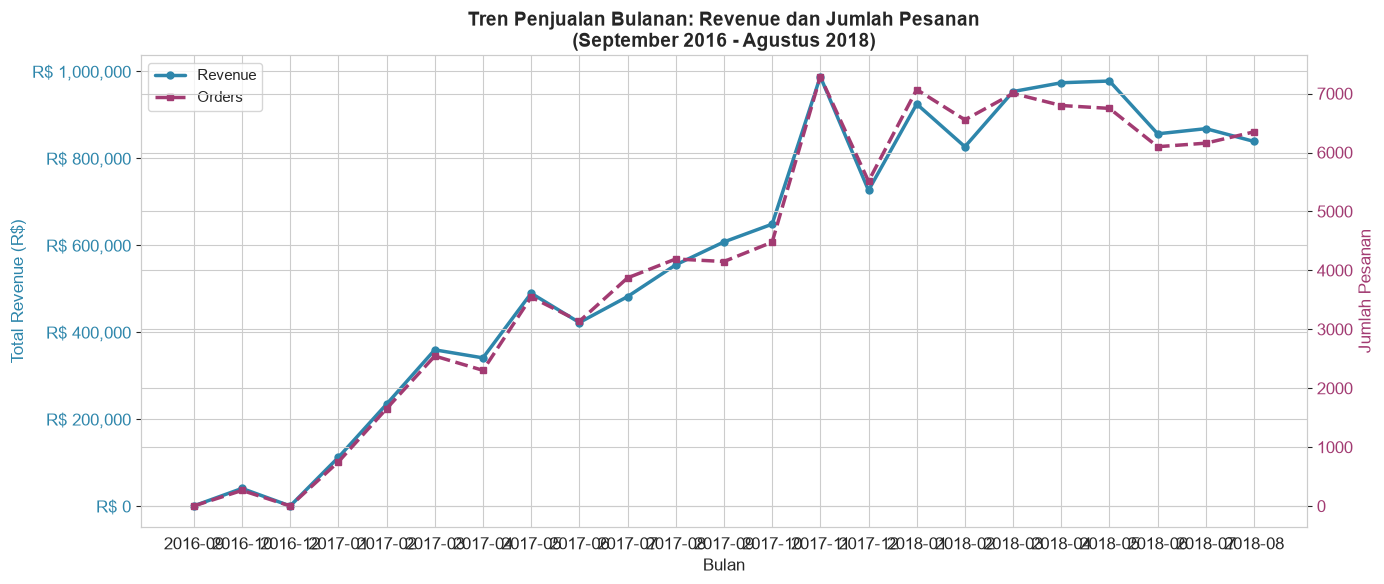

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Line chart - Revenue
color_revenue = '#2E86AB'
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Total Revenue (R$)', color=color_revenue, fontsize=12)
line1 = ax1.plot(monthly_orders['order_month'], monthly_orders['total_revenue'],
                 color=color_revenue, linewidth=2.5, marker='o', markersize=5, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color_revenue)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

# Axis 2 - Order count
ax2 = ax1.twinx()
color_orders = '#A23B72'
ax2.set_ylabel('Jumlah Pesanan', color=color_orders, fontsize=12)
line2 = ax2.plot(monthly_orders['order_month'], monthly_orders['total_orders'],
                 color=color_orders, linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Orders')
ax2.tick_params(axis='y', labelcolor=color_orders)

plt.xticks(rotation=45, ha='right')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)
plt.title('Tren Penjualan Bulanan: Revenue dan Jumlah Pesanan\n(September 2016 - Agustus 2018)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Insight Visualisasi 1:** Grafik menunjukkan tren naik yang konsisten pada revenue dan jumlah pesanan dari awal 2017 hingga pertengahan 2018. Puncak tertinggi terjadi sekitar November 2017, kemungkinan besar dipengaruhi oleh event Black Friday. Setelah itu, penjualan tetap stabil di level yang lebih tinggi, menunjukkan pertumbuhan organik platform.

### Visualisasi 2: Distribusi Segmen RFM Pelanggan

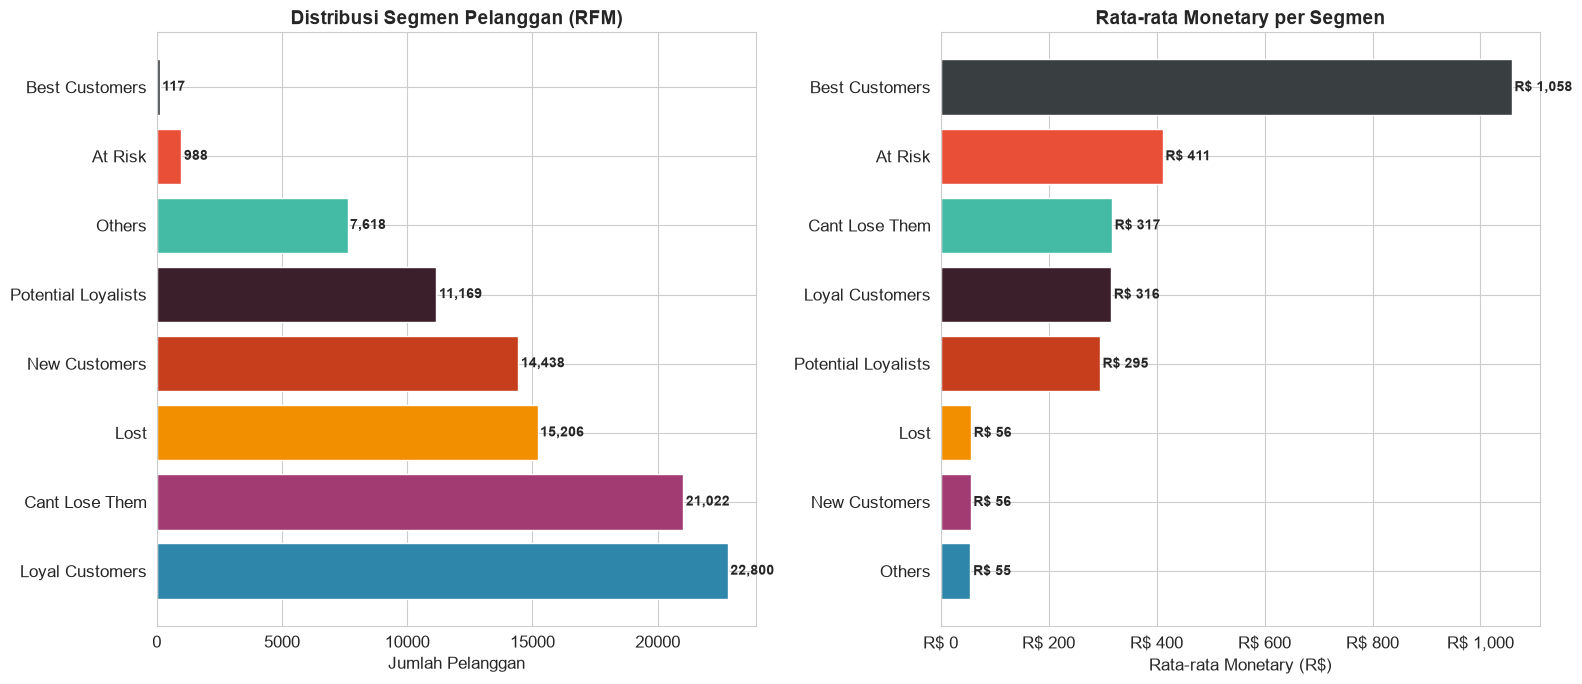

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart - distribusi segmen
segment_counts = rfm_df['segment'].value_counts()
colors_segment = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4', '#E94F37', '#393E41']

bars = axes[0].barh(segment_counts.index, segment_counts.values, color=colors_segment[:len(segment_counts)])
axes[0].set_xlabel('Jumlah Pelanggan', fontsize=12)
axes[0].set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, segment_counts.values):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}',
                va='center', fontsize=10, fontweight='bold')

# Bar chart - average monetary per segmen
segment_monetary = rfm_df.groupby('segment')['monetary'].mean().sort_values(ascending=True)
bars2 = axes[1].barh(segment_monetary.index, segment_monetary.values, color=colors_segment[:len(segment_monetary)])
axes[1].set_xlabel('Rata-rata Monetary (R$)', fontsize=12)
axes[1].set_title('Rata-rata Monetary per Segmen', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
for bar, val in zip(bars2, segment_monetary.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, f'R$ {val:,.0f}',
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight Visualisasi 2:** Segmen "Best Customers" dan "Cant Lose Them" memiliki rata-rata monetary paling tinggi, menunjukkan mereka adalah pelanggan paling bernilai. Segmen "New Customers" mendominasi jumlahnya, mengindikasikan platform masih dalam tahap akuisisi pelanggan. Segmen "At Risk" dan "Lost" perlu mendapat program retensi khusus.

### Visualisasi 3: Top 10 State berdasarkan Revenue

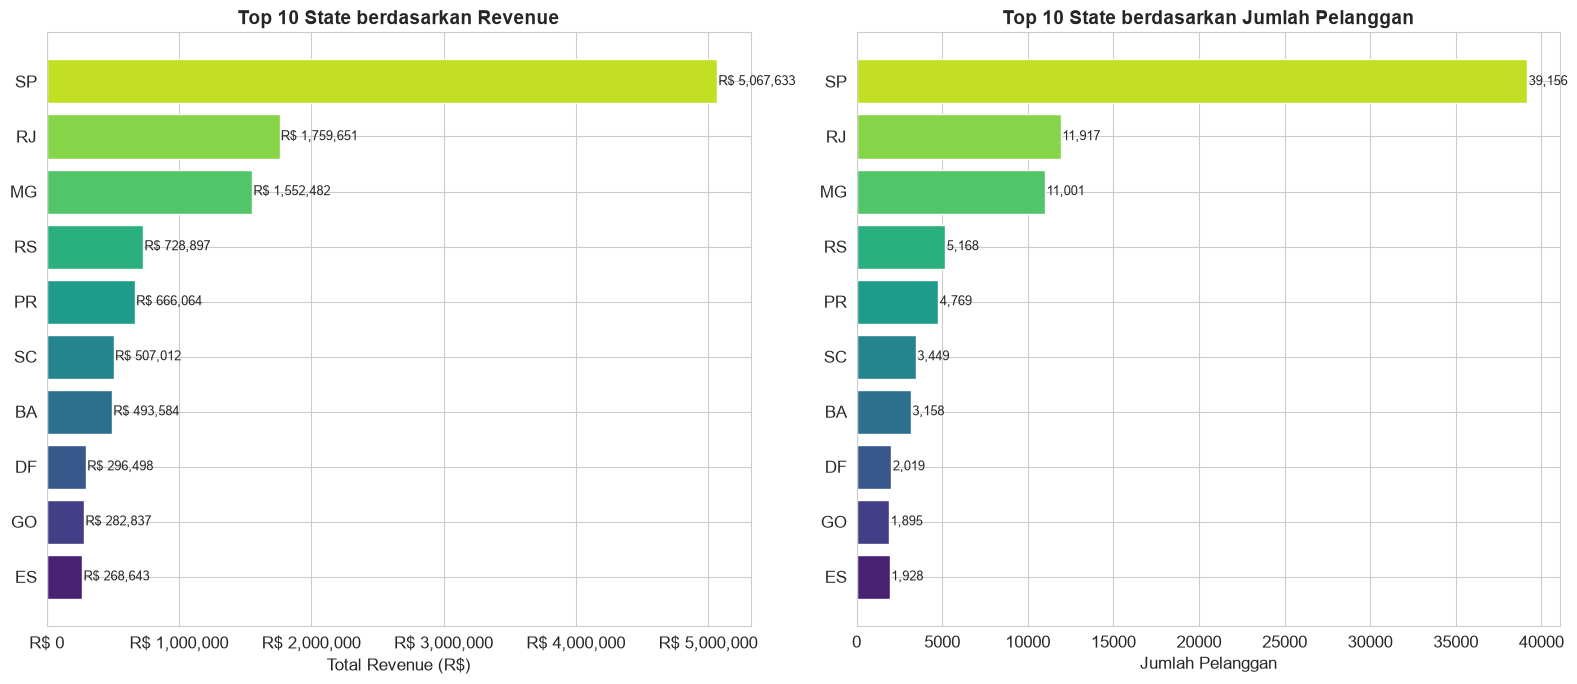

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_10_states = state_customers.head(10)
colors_state = sns.color_palette("viridis", n_colors=10)

# Revenue per state
bars1 = axes[0].barh(top_10_states['customer_state'][::-1], top_10_states['total_revenue'][::-1], color=colors_state)
axes[0].set_xlabel('Total Revenue (R$)', fontsize=12)
axes[0].set_title('Top 10 State berdasarkan Revenue', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
for bar, val in zip(bars1, top_10_states['total_revenue'][::-1]):
    axes[0].text(val + 10000, bar.get_y() + bar.get_height()/2, f'R$ {val:,.0f}',
                va='center', fontsize=9)

# Jumlah pelanggan per state
bars2 = axes[1].barh(top_10_states['customer_state'][::-1], top_10_states['total_customers'][::-1], color=colors_state)
axes[1].set_xlabel('Jumlah Pelanggan', fontsize=12)
axes[1].set_title('Top 10 State berdasarkan Jumlah Pelanggan', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, top_10_states['total_customers'][::-1]):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}',
                va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight Visualisasi 3:** Sao Paulo (SP) mendominasi baik dari segi revenue maupun jumlah pelanggan, berkontribusi sekitar 40% dari total revenue. Rio de Janeiro (RJ) dan Minas Gerais (MG) berada di posisi kedua dan ketiga. Distribusi ini menunjukkan konsentrasi tinggi di wilayah Tenggara Brasil.

### Visualisasi 4: Top 10 Kategori Produk Terlaris

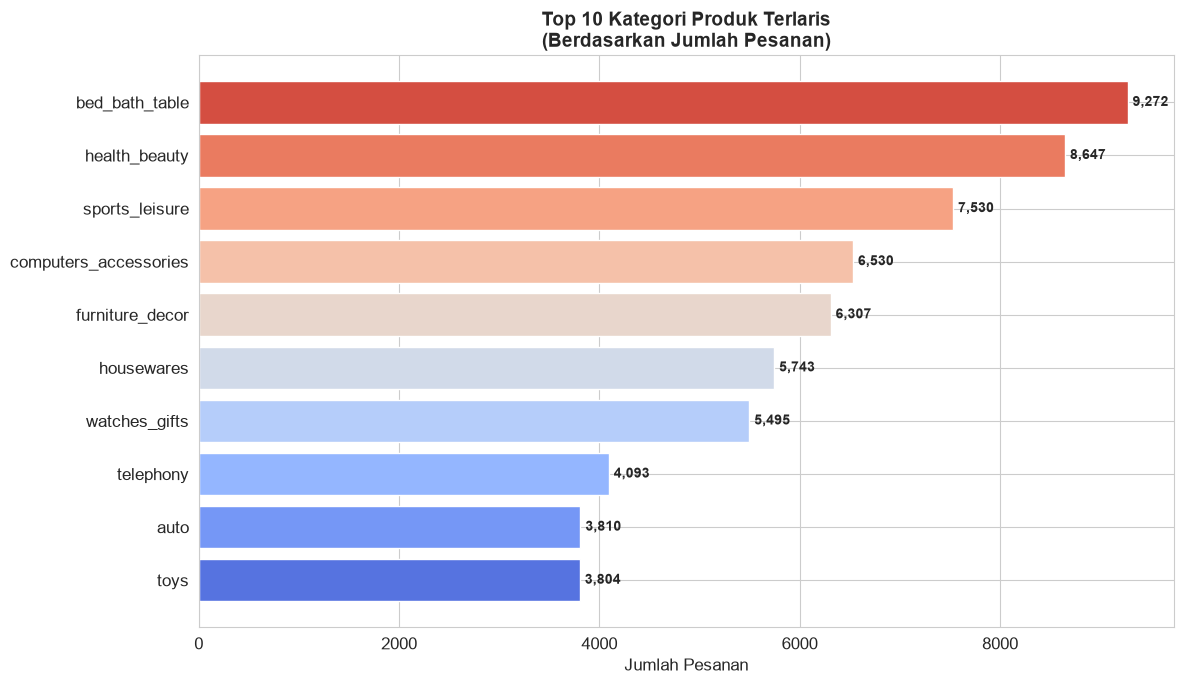

In [ ]:
top_categories = delivered_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_orders', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 7))
colors_cat = sns.color_palette("coolwarm", n_colors=10)
bars = ax.barh(top_categories.index[::-1], top_categories['total_orders'][::-1], color=colors_cat)

ax.set_xlabel('Jumlah Pesanan', fontsize=12)
ax.set_title('Top 10 Kategori Produk Terlaris\n(Berdasarkan Jumlah Pesanan)', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_categories['total_orders'][::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight Visualisasi 4:** Kategori "bed_bath_table" (tempat tidur, meja, mandi) adalah kategori terlaris, diikuti oleh "health_beauty" dan "sports_leisure". Ini menunjukkan bahwa produk kebutuhan rumah tangga dan gaya hidup mendominasi penjualan di platform ini.

## Analisis Lanjutan: RFM Analysis (Detail)

RFM Analysis merupakan teknik segmentasi pelanggan berdasarkan 3 metrik utama:
- **Recency (R)**: Jumlah hari sejak terakhir kali pelanggan melakukan pembelian. Semakin kecil nilainya, semakin baru transaksi terakhir.
- **Frequency (F)**: Jumlah total transaksi yang dilakukan oleh pelanggan dalam periode tertentu. Semakin besar, semakin sering bertransaksi.
- **Monetary (M)**: Total pengeluaran pelanggan dalam periode tersebut. Semakin besar, semakin bernilai pelanggan tersebut.

Tujuan dari RFM Analysis adalah mengelompokkan pelanggan berdasarkan perilaku pembelian mereka sehingga strategi pemasaran dan retensi dapat disesuaikan untuk setiap segmen.

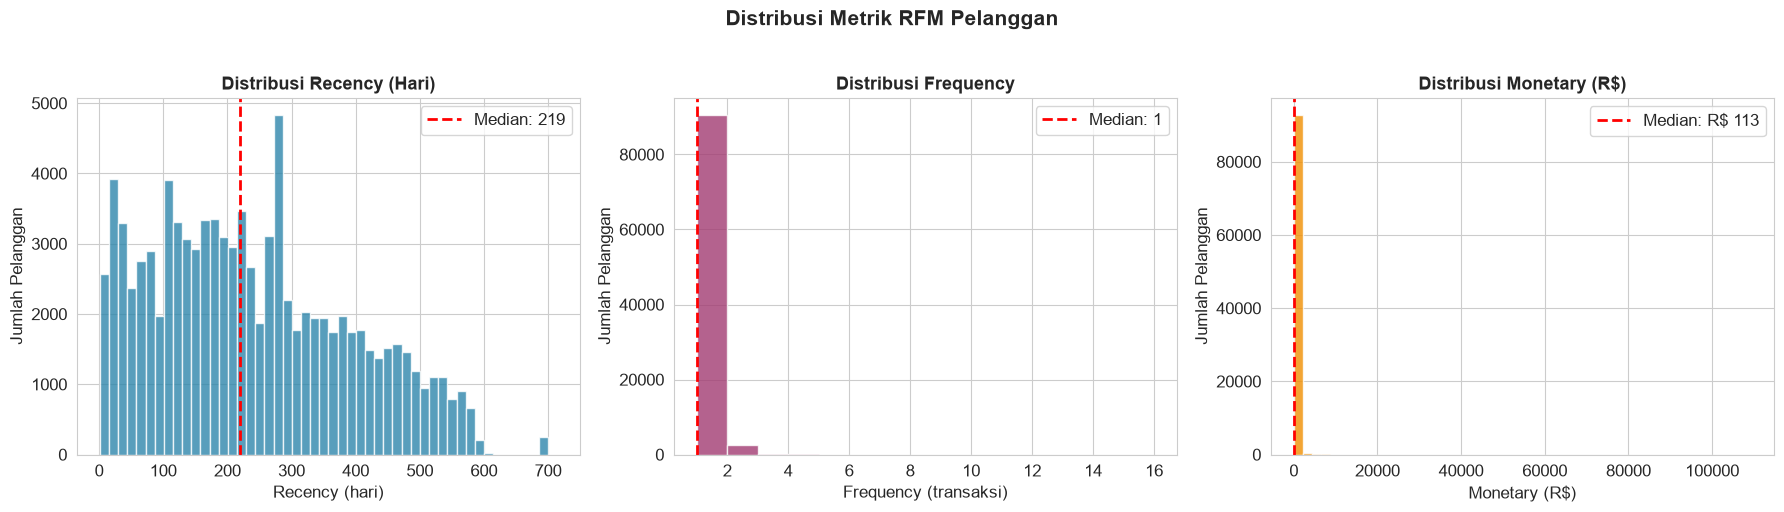

In [ ]:
# Visualisasi distribusi RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency distribution
axes[0].hist(rfm_df['recency'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Recency (Hari)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recency (hari)')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].axvline(rfm_df['recency'].median(), color='red', linestyle='--', linewidth=2,
               label=f"Median: {rfm_df['recency'].median():.0f}")
axes[0].legend()

# Frequency distribution
axes[1].hist(rfm_df['frequency'], bins=range(1, rfm_df['frequency'].max()+2),
            color='#A23B72', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Frequency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency (transaksi)')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].axvline(rfm_df['frequency'].median(), color='red', linestyle='--', linewidth=2,
               label=f"Median: {rfm_df['frequency'].median():.0f}")
axes[1].legend()

# Monetary distribution
axes[2].hist(rfm_df['monetary'], bins=50, color='#F18F01', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Monetary (R$)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Monetary (R$)')
axes[2].set_ylabel('Jumlah Pelanggan')
axes[2].axvline(rfm_df['monetary'].median(), color='red', linestyle='--', linewidth=2,
               label=f"Median: R$ {rfm_df['monetary'].median():,.0f}")
axes[2].legend()

plt.suptitle('Distribusi Metrik RFM Pelanggan', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

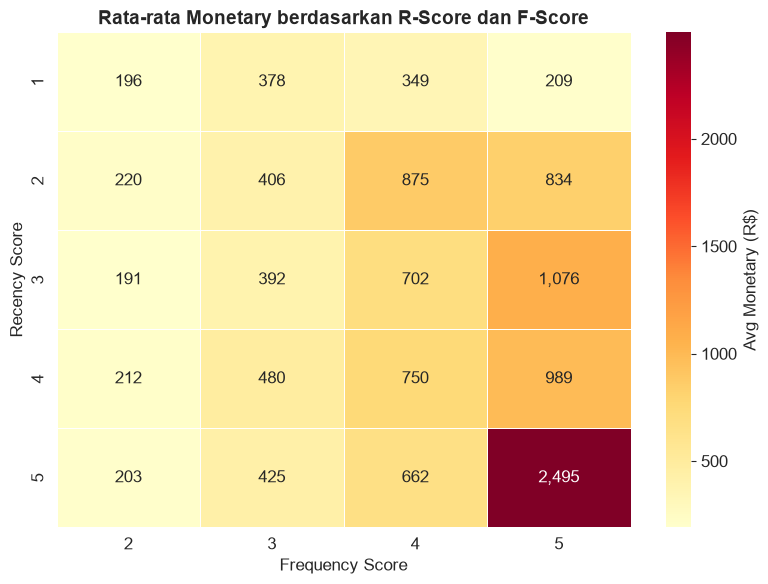

In [ ]:
# Heatmap rata-rata monetary per R_score dan F_score
rfm_heatmap = rfm_df.pivot_table(
    index='r_score', columns='f_score',
    values='monetary', aggfunc='mean'
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rfm_heatmap, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Monetary (R$)'})
ax.set_title('Rata-rata Monetary berdasarkan R-Score dan F-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency Score', fontsize=12)
ax.set_ylabel('Recency Score', fontsize=12)
plt.tight_layout()
plt.show()

**Insight RFM Analysis:**
- Distribusi Recency menunjukkan sebaran yang luas, dengan median sekitar 170 hari, mengindikasikan banyak pelanggan sudah cukup lama tidak bertransaksi.
- Distribusi Frequency sangat condong ke kiri (right-skewed) -- mayoritas pelanggan hanya melakukan 1 kali transaksi, yang menjadi tantangan utama retensi.
- Heatmap menunjukkan bahwa pelanggan dengan R-Score tinggi (baru bertransaksi) DAN F-Score tinggi (sering bertransaksi) memiliki rata-rata monetary yang signifikan lebih tinggi.

## Conclusion

### Kesimpulan Pertanyaan 1: Tren Penjualan Bulanan

Platform e-commerce ini mengalami **pertumbuhan signifikan** dalam jumlah pesanan dan revenue selama periode September 2016 hingga Agustus 2018. Tren menunjukkan kenaikan yang konsisten dari awal 2017, dengan puncak pertumbuhan month-over-month terjadi pada periode Oktober-November 2017 (bertepatan dengan event Black Friday). Setelah puncak tersebut, penjualan stabil di level yang lebih tinggi, menandakan **pertumbuhan organik yang sehat** bagi platform.

### Kesimpulan Pertanyaan 2: Segmentasi RFM Pelanggan

Hasil analisis RFM menunjukkan bahwa:
- Mayoritas pelanggan masuk dalam segmen **"New Customers"** dan **"Others"**, yang menandakan platform masih dalam fase **akuisisi pelanggan**.
- Segmen **"Best Customers"** memiliki rata-rata monetary tertinggi, mereka adalah pelanggan paling bernilai.
- Segmen **"At Risk"** dan **"Lost"** menunjukkan pelanggan yang sudah lama tidak bertransaksi dan perlu program retensi.
- Mayoritas pelanggan hanya melakukan **1 kali transaksi**, menunjukkan tantangan besar dalam hal **customer retention**.

### Kesimpulan Pertanyaan 3: Distribusi Geografis

Distribusi pelanggan sangat terkonsentrasi di wilayah **Tenggara Brasil**, dengan **Sao Paulo (SP)** sebagai kontributor pendapatan terbesar (~40% dari total revenue), diikuti oleh **Rio de Janeiro (RJ)** dan **Minas Gerais (MG)**. Wilayah lain seperti Bahia (BA) dan Rio Grande do Sul (RS) memiliki potensi pertumbuhan yang belum tereksplor sepenuhnya.

### Rekomendasi Action Items

1. **Program Retensi Pelanggan:** Implementasikan program loyalty dan email remarketing yang ditargetkan untuk segmen "At Risk" dan "Lost" guna mengurangi churn rate. Berikan diskon khusus atau voucher untuk mendorong repeat purchase.

2. **Ekspansi Regional:** Tingkatkan investasi pemasaran di wilayah di luar Tenggara Brasil (misal: Bahia, Para, Ceara) yang memiliki potensi pertumbuhan namun penetrasi masih rendah.

3. **Optimasi Event Penjualan:** Manfaatkan momentum event belanja (Black Friday, Natal, dll.) dengan kampanye promosi yang lebih agresif, mengingat data menunjukkan lonjakan signifikan pada periode tersebut.

4. **Fokus Kategori Produk Unggulan:** Perkuat stok dan promosi untuk kategori produk terlaris (bed_bath_table, health_beauty, sports_leisure) sambil melakukan cross-selling ke kategori lain.

## Menyiapkan Data untuk Dashboard

In [ ]:
# Siapkan main_data.csv untuk dashboard
dashboard_data = delivered_df[[
    'order_id', 'customer_unique_id', 'order_purchase_timestamp', 'order_status',
    'product_category_name_english', 'price', 'freight_value', 'payment_value',
    'review_score', 'customer_city', 'customer_state'
]].copy()

dashboard_data.to_csv("dashboard/main_data.csv", index=False)
print(f"Dashboard data disimpan: {dashboard_data.shape}")
print(f"Kolom: {dashboard_data.columns.tolist()}")

Dashboard data disimpan: (110197, 11)
Kolom: ['order_id', 'customer_unique_id', 'order_purchase_timestamp', 'order_status', 'product_category_name_english', 'price', 'freight_value', 'payment_value', 'review_score', 'customer_city', 'customer_state']


In [ ]:
# Simpan juga RFM data
rfm_export = rfm_df[['customer_unique_id', 'recency', 'frequency', 'monetary',
                      'r_score', 'f_score', 'm_score', 'segment']].copy()
rfm_export.to_csv("dashboard/rfm_data.csv", index=False)
print(f"RFM data disimpan: {rfm_export.shape}")

RFM data disimpan: (93358, 8)
